In [ ]:
# Import necessary libraries for the project
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

# Verify PyTorch installation
print(f"Libraries loaded successfully. PyTorch version: {torch.__version__}")

Libraries loaded successfully. PyTorch version: 2.12.1+cpu


Fetching historical data for MSFT...


[*********************100%***********************]  1 of 1 completed


Data successfully loaded ! Here are the first 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2014-01-02,30.694433,30.892676,30.644872,30.851373,30632200
2014-01-03,30.487936,30.743999,30.231873,30.727479,31134800
2014-01-06,29.843662,30.471427,29.827142,30.438386,43603700
2014-01-07,30.074930,30.141012,29.909728,30.008851,35802800
2014-01-08,29.538023,29.851907,29.389345,29.736266,59971700


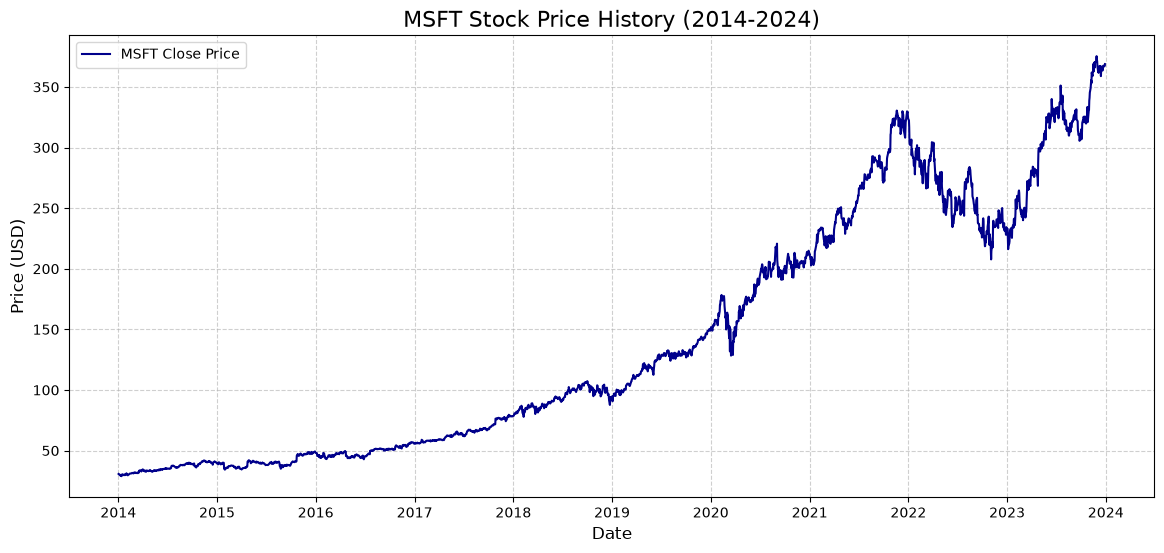

In [2]:
# 1. Define the stock ticker and the time range
ticker = 'MSFT'


start_date = '2014-01-01'
end_date = '2024-01-01'

# 2. Download the data using yfinance API
print(f"Fetching historical data for {ticker}...")
data = yf.download(ticker, start = start_date, end = end_date)

# 3. View the structure of our data
print("\nData successfully loaded ! Here are the first 5 rows:"),
# display() : html format / a table
display(data.head()) 

# 4. Visualize the 'Close' price to understand the historical trend
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label=f'{ticker} Close Price', color ='darkblue')

plt.title(f"{ticker} Stock Price History (2014-2024)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



In [ ]:
# 1. Extract only the 'Close' column and convert it to a 2D NumPy array
prices = data[['Close']].values

# 2. Initialize the scaler to compress data between -1 and 1

scaler = MinMaxScaler(feature_range=(-1,1))

scaled_data = scaler.fit_transform(prices)

# 4. Verify the scaling process

print("--- Scaling Process Successful! ---")
print(f"Original Minimum Price: {prices.min():.2f} USD | Original Maximum Price:{prices.max():.2f} USD")
print(f"Scaled Min Value: {scaled_data.min():.2f} | Scaled Max Value: {scaled_data.max():.2f}\n")

print("First 5 days of scaled data:")
print(scaled_data[:5])

--- Scaling Process Successful! ---
Original Minimum Price: 28.89 USD | Original Maximum Price:375.41 USD
Scaled Min Value: -1.00 | Scaled Max Value: 1.00

First 5 days of scaled data:
[[-0.99079863]
 [-0.99451725]
 [-0.99318242]
 [-0.99628134]]


In [ ]:
import numpy as np

def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        window = data[i:(i + window_size)]
        target = data[i + window_size]

        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

WINDOW_SIZE = 20
X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("--- Sequence Creation Successful! ---")
print(f"Total sequences created: {len(X)}")
print(f"Shape of X (Inputs): {X.shape} -> (Total Samples, Window Size, Features)")
print(f"Shape of y (Targets): {y.shape} -> (Total Samples, Features)")